# 🏃‍♂️ MediaPipe Holistic Keypoint Extraction

## Credits
This notebook is adapted from [Clough et al. (2026)'s Kinematics Lecture Series -- Lecture 4](https://github.com/Multimodal-Language-Department-MPI-NL/Kinematics-Lecture-Series/tree/main/scripts/Lecture4_MediaPipe_Extraction).

## Overview
To prepare for kinematic analysis of gestures or automatic detection of gestures, we first need to extract motion tracking data from videos. This notebook uses python libraries to extract human pose landmarks from videos using **Google's [MediaPipe Holistic](https://github.com/google-ai-edge/mediapipe/blob/master/docs/solutions/holistic.md)** model. We save the extracted data in CSV files for later kinematic analysis. We also show how to overlay landmark skeletons onto your original videos.

## Sections
-  **1️⃣ Environmental Setup**: This section includes instructions on how to set up a virtual environment with required packages, check that dependencies are met, and import required packages.
-  **2️⃣ Live pose estimation**: This section performs live pose estimation by running MediaPipe on the webcam feed.  
-  **3️⃣ Extract MediaPipe Holistic Landmarks**: This section defines and implements functions for extracting 33 body landmarks (with X, Y, Z coordinates + visibility scores), 42 hand landmarks (21 per hand, with X, Y, Z coordinates), and 478 face landmarks (with X, Y, Z coordinates). It loops through all videos in the input folder and saves (i) the motion tracking data in a single CSV file for each videos (e.g., video_name.csv) and (ii) the output videos with lardmark skeleton overlayed on top of the original videos.
-  **4️⃣ Visualize Motion Tracking Data**: This section shows how to visualize motion tracking data over time for a given landmark (e.g., right wrist) using Plotly.

***

# **1️⃣** Setting up

## ⚙️ 1.1 Environment Setup
First, we import the python packages we'll be using for MediaPipe extraction. We also setup our folder paths, telling the script where to find the videos we'll be analyzing and where to store the results. After running the cell below, you should see a printed output message saying there are 8 videos to process.

In [1]:
# Import required libraries
import os
import cv2
import numpy as np
import pandas as pd
import csv
from os import listdir
from os.path import isfile, join
from IPython.display import display, Video
import plotly.graph_objects as go
from IPython.display import Image
import mediapipe as mp
from utils import run_mediapipe

# commands to make the notebook interactive and automatically reload modified modules
%load_ext autoreload
%autoreload 2
%matplotlib inline

# Configure folder paths
input_folder = "input_videos"   # Path to find videos
output_folder = "output_folder" # Path to store results

# Display configuration
print(f"Input folder: {os.path.abspath(input_folder)}")
print(f"Output folder: {os.path.abspath(output_folder)}")

Input folder: /Users/shoakamine/ownCloud/Research/Teaching/2026/swift-mlp/Tutorial_1_Pose_Estimation_with_MediaPipe/input_videos
Output folder: /Users/shoakamine/ownCloud/Research/Teaching/2026/swift-mlp/Tutorial_1_Pose_Estimation_with_MediaPipe/output_folder


## 🔧 1.2 MediaPipe Configuration
MediaPipe tracks coordinates of the following landmarks:

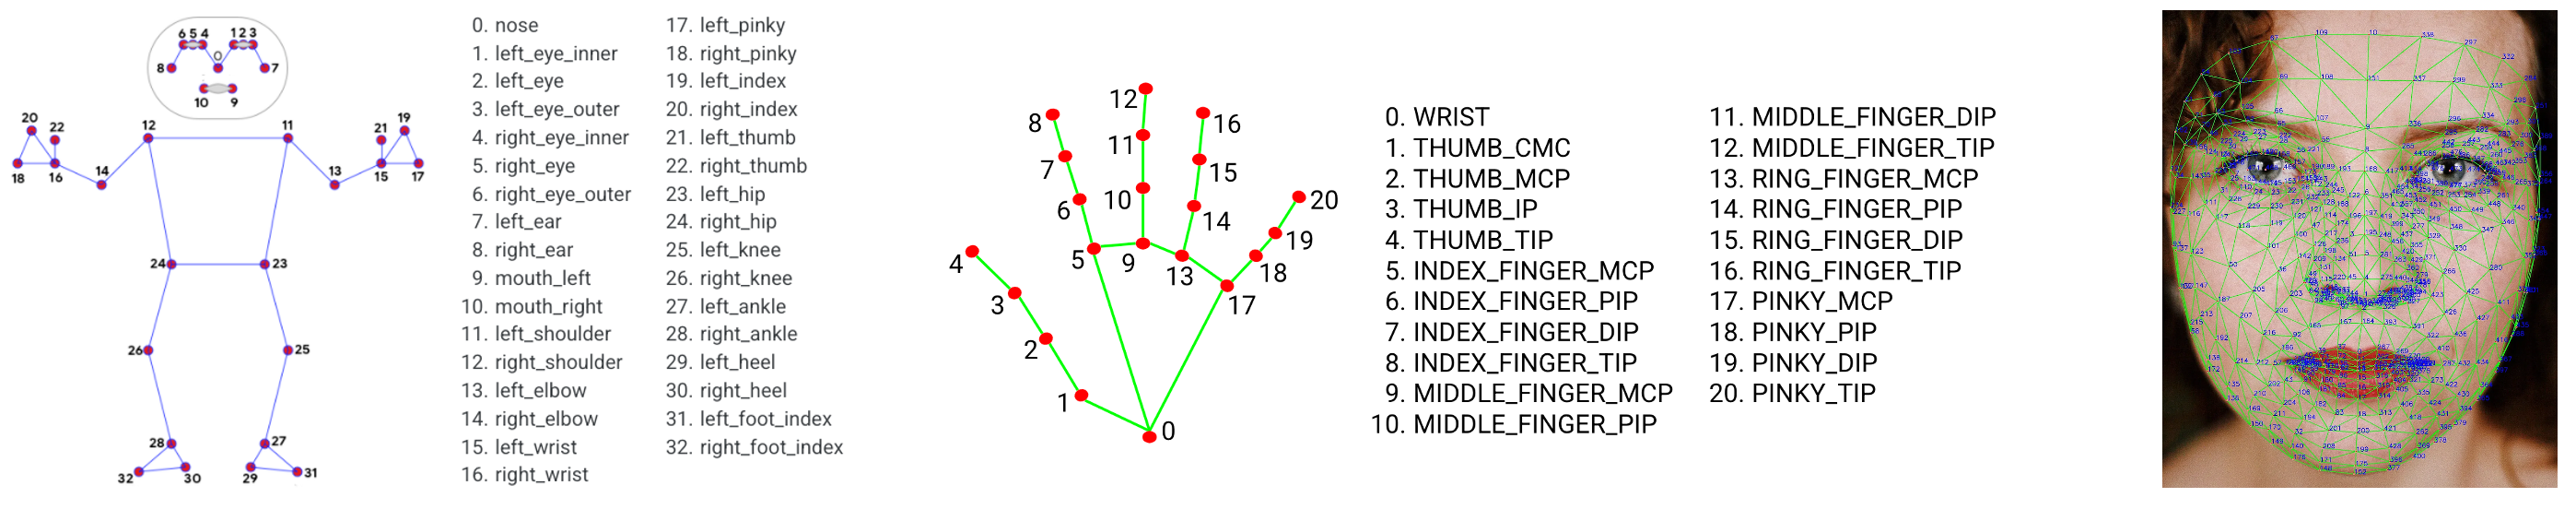

In [4]:
display(Image(filename='images/MediaPipe_landmarks.png', width =1400))

In this module, we only track coordinates of the body and hands, as the face model is quite heavy (tracks 468 landmarks).

Use the options in the next code cell to choose which landmarks to extract and how MediaPipe processes the video. Here are some important options:

| Option | Typical values | Explanation |
|---|---|---|
| `webcam_mode` | `True` or `False` | Use webcam input instead of processing videos from `input_folder`. |
| `save_overlay_video` | `True` or `False` | Save videos with extracted landmarks drawn on top. |
| `static_image_mode` | `True` or `False` | Process frames independently (`False`) or track landmarks across video frames (`True`). Set this to `True` for videos.|
| `model_complexity` | `0`, `1`, or `2` | Higher values generally improve accuracy but reduce processing speed. |

Experiment with these settings to balance extraction speed, accuracy, temporal stability, and output requirements. If you are unsure about these settings, the default settings would most likely work for you.

In [2]:
# Here, you may choose whether you want to extract motion tracking data for the body, hands, or face. 
# Set to True to extract motion tracking data
mp_options = {
    "body_csv": True,
    "body_world_csv": False,
    "hands_csv": True,
    "face_csv": False,
    "webcam_mode": False,
    "show_overlay": True,
    "save_overlay_video": True
}

# Here, you may choose options for the MediaPipe Holistic model. 
# These options control how the model processes the video frames and extracts landmarks.
# If you are unsure, the default settings are recommended for most use cases.
mp_model_options = {
    "static_image_mode": False,     # default False means images are related (i.e., video stream), True would mean images are independent
    "model_complexity": 2,          # defaut 1; 2 is the best but slowest, 0 is the worst but fastest
    "enable_segmentation": False,   # set True if you want the model to separate the person/body pixels from the background pixels (not needed for us)
    "refine_face_landmarks": False, # default False. Whether to refine the face landmarks. True = "Slightly slower processing due to the extra computational step."
    "smooth_landmarks": True,
    "min_detection_confidence": 0.7,
    "min_tracking_confidence": 0.7
}

# **2️⃣** Live Pose Estimation

In [ ]:
mp_options["webcam_mode"] = True
# press 'Esc' key to quit the webcam mode
run_mediapipe(input_folder, output_folder, mp_options, mp_model_options)


Processing video 1/1: webcam_capture
Video properties:
  Resolution: 1920x1080
  FPS: 15.0
  Total frames: live webcam


I0000 00:00:1788775471.687953 2173074 gl_context.cc:369] GL version: 2.1 (2.1 Metal - 90.5), renderer: Apple M4
INFO: Created TensorFlow Lite XNNPACK delegate for CPU.
W0000 00:00:1788775471.770663 2173335 inference_feedback_manager.cc:114] Feedback manager requires a model with a single signature inference. Disabling support for feedback tensors.
W0000 00:00:1788775471.823253 2173336 inference_feedback_manager.cc:114] Feedback manager requires a model with a single signature inference. Disabling support for feedback tensors.
W0000 00:00:1788775471.825201 2173332 inference_feedback_manager.cc:114] Feedback manager requires a model with a single signature inference. Disabling support for feedback tensors.
W0000 00:00:1788775471.825851 2173341 inference_feedback_manager.cc:114] Feedback manager requires a model with a single signature inference. Disabling support for feedback tensors.
W0000 00:00:1788775471.826013 2173336 inference_feedback_manager.cc:114] Feedback manager requires a mod

Saved overlay video: output_folder/output_videos/webcam_capture_overlay.mp4
Saved: output_folder/output_timeseries/webcam_capture.csv (0 frames)

Processing complete!
All files saved to: /Users/shoakamine/ownCloud/Research/Teaching/2026/swift-mlp/Tutorial_1_Pose_Estimation_with_MediaPipe/output_folder/output_timeseries


: 

# **3️⃣** Extract MediaPipe Holistic Landmarks

This is our main function which processes videos from our input folder and creates CSV files containing motion tracking data for the body, hands, and face. It saves one CSV file per video.

In [6]:
mp_options["webcam_mode"] = False
run_mediapipe(input_folder, output_folder, mp_options, mp_model_options)


Skipping video 1/1: salma_hayek_short.mp4 (CSV already exists)

Processing complete!
All files saved to: /Users/shoakamine/ownCloud/Research/Teaching/2026/swift-mlp/Tutorial_1_Pose_Estimation_with_MediaPipe/output_folder/output_timeseries


## 📝 Exercise 1
Examine the output video and answer the following questions:

1. On a scale of 1 to 5 (1 = terrible, 2 = not good, 3 = acceptable, 4 = good, 5 = excellent), how accurate is the MediaPipe motion tracking?

2. When does MediaPipe fail to accuratly estimate pose?

3. Which model is more stable, body model (red points with grey lines) or hand model (pink/orange points with yellow/blue lines)? 

<details>
  <summary><b style='color:darkorange;'>Click here for an answer</b></summary>
  
  1. I would say 4 for body model and 5 for hand model

  2. There are a few scenarios where MP seems to fail: <br>
    1. When the camera switches from one person to another <br>
    2. When there are multiple people in a single frame <br>
    3. When the hand moves too fast and the image gets blurry <br>
    4. When the joint is occluded (e.g., the left hand occluded by the right hand)

  3. Hand model is more stable because it has less jitter. This means that when analyzing kinematics of hand keypoints (e.g., wrists), using data from the hand model (e.g., `LEFT_WRIST_HAND`) is often better than data from the body model (e.g., `LEFT_WRIST`). Usually, we apply some preprocessing to reduce jitter in the data. For details, see [Lecture 5 of the Kinematics Lecture Series](https://github.com/Multimodal-Language-Department-MPI-NL/Kinematics-Lecture-Series/blob/main/scripts/Lecture5_Smoothing_and_Normalization/L5_Smoothing_and_Normalization.ipynb).

</details>

## 📝 Exercise 2
Examine the output CSV file and figure out what each row corresponds to.

Hint: The frame rate of the video is 29.97 FPS, meaning that the video contains 29.97 images per second. Therefore, the first frame is at 33.37 ms, next frame is 66.73, and so forth.

In [6]:
output_to_examine = "output_folder/output_timeseries/salma_hayek_short.csv"

df = pd.read_csv(output_to_examine)
df.head(5)

,Time,X_NOSE,Y_NOSE,Z_NOSE,visibility_NOSE,X_LEFT_EYE_INNER,Y_LEFT_EYE_INNER,Z_LEFT_EYE_INNER,visibility_LEFT_EYE_INNER,X_LEFT_EYE,...,Z_RIGHT_PINKY_MCP,X_RIGHT_PINKY_PIP,Y_RIGHT_PINKY_PIP,Z_RIGHT_PINKY_PIP,X_RIGHT_PINKY_DIP,Y_RIGHT_PINKY_DIP,Z_RIGHT_PINKY_DIP,X_RIGHT_PINKY_TIP,Y_RIGHT_PINKY_TIP,Z_RIGHT_PINKY_TIP
0,0.000000,0.452190,0.253005,-0.302933,0.995209,0.476258,0.209325,-0.291068,0.984927,0.487533,...,-0.028363,0.217376,0.614931,-0.036181,0.215459,0.615013,-0.037894,0.213091,0.613449,-0.040096
1,33.366667,0.451981,0.253082,-0.380240,0.995465,0.475323,0.210000,-0.376133,0.985890,0.485595,...,-0.030052,0.216647,0.621667,-0.038194,0.212958,0.620213,-0.041016,0.208801,0.617309,-0.043867
2,66.733333,0.451997,0.253194,-0.473883,0.995673,0.475144,0.211043,-0.471203,0.986761,0.484892,...,-0.034329,0.211763,0.619384,-0.044539,0.208501,0.617812,-0.048566,0.205098,0.614676,-0.052331
3,100.100000,0.451403,0.252937,-0.453326,0.995894,0.474311,0.211244,-0.448128,0.987588,0.483750,...,-0.035027,0.212185,0.616156,-0.045430,0.208226,0.614287,-0.049903,0.203465,0.609846,-0.054161
4,133.466667,0.449001,0.252596,-0.412338,0.996178,0.471955,0.211497,-0.406982,0.988527,0.480561,...,-0.030713,0.214513,0.606137,-0.039271,0.212586,0.602402,-0.042297,0.210861,0.597744,-0.045456


# **4️⃣** Visualize Motion Tracking Data
What does motion tracking data actually look like? In this code, we read in the MediaPipe motion tracking data for one of our videos. MediaPipe provides X, Y, and Z coordinates for each body joint in every frame of the video. Here, we visualize how the position of the right wrist changes over time. 

The X-value represents  horizontal position (left to right) and is normalized between 0 and 1 relative to the image width. Similarly, the Y-value represents vertical position (top to bottom) and is normalized between 0 and 1 relative to the image height. The X and Y values are image-based coordinates, describing where a joint appears in each video frame. 

The Z-value represents depth (forward to backward). Unlike X and Y, Z is not directly measured from the image but inferred from the model's training data. Negative Z-values indicate that the body landmark is closer to the camera. However, you can see from this plot that Z estimates are generally noiser and exist on a different scale than the X and Y values. It is also important to note that MediaPipe uses different depth reference points in different models. In the body model, depth is referenced to the midhip  whereas in the hand model, depth is referenced to the the wrist. Because of these differences and the higher variability in Z, we will focus only on X and Y values in this lecture series.

In [ ]:
# Read in one of the CSV files we created in Section 2
df = pd.read_csv(os.path.join(csv_folder, 'salma_hayek_short.csv'))

# Create a plot visualizing the X, Y, and Z position of the right wrist across the entire video time series
fig = go.Figure()
# Add your data traces
fig.add_trace(go.Scatter(x=df['Time'], y=df["X_RIGHT_WRIST"], mode='lines', name='X_RIGHT_WRIST', line=dict(color='#80BBB4')))
fig.add_trace(go.Scatter(x=df['Time'], y=df["Y_RIGHT_WRIST"], mode='lines', name='Y_RIGHT_WRIST', line=dict(color='#00786A')))
fig.add_trace(go.Scatter(x=df['Time'], y=df["Z_RIGHT_WRIST"], mode='lines', name='Z_RIGHT_WRIST', line=dict(color='#00483F')))

fig.update_layout(
    title="Right Wrist Position Over Time",
    xaxis_title="Time (milliseconds)",
    yaxis_title="Position",
    template="plotly_white"
)

fig.show()

# 🎯 Summary

Congratulations! You have now successfully extracted MediaPipe motion tracking data from videos! In the output folder, you will find CSV files containing the motion tracking data for each video as well as new videos displaying motion tracking skeletons on top of the original videos. You can also extract motion tracking data from your own videos. Just replace the videos in the `input_videos` folder with your own videos and re-run the script from the beginning.

Now that we have extracted motion tracking data, the real fun begins. In the next tutorial, you will learn how to automatically segment gestures based on motion tracking data. 
